In [1]:
import numpy as np
from matplotlib import pyplot as plt

a=2
b=4.5
c=1
d=1

s_plus = (b*d**2+c*a**2)/(d*c*a)
u_plus = c*a**2/(c*a**2+b*d**2)
u_minus = 0

lambda4 = -b-a/s_plus -d*(1-2*u_plus) + c*s_plus**2*(2*u_plus - 3*u_plus**2)

s_plus, u_plus

(4.25, 0.47058823529411764)

Plot for the condition of $\tilde{\lambda}$

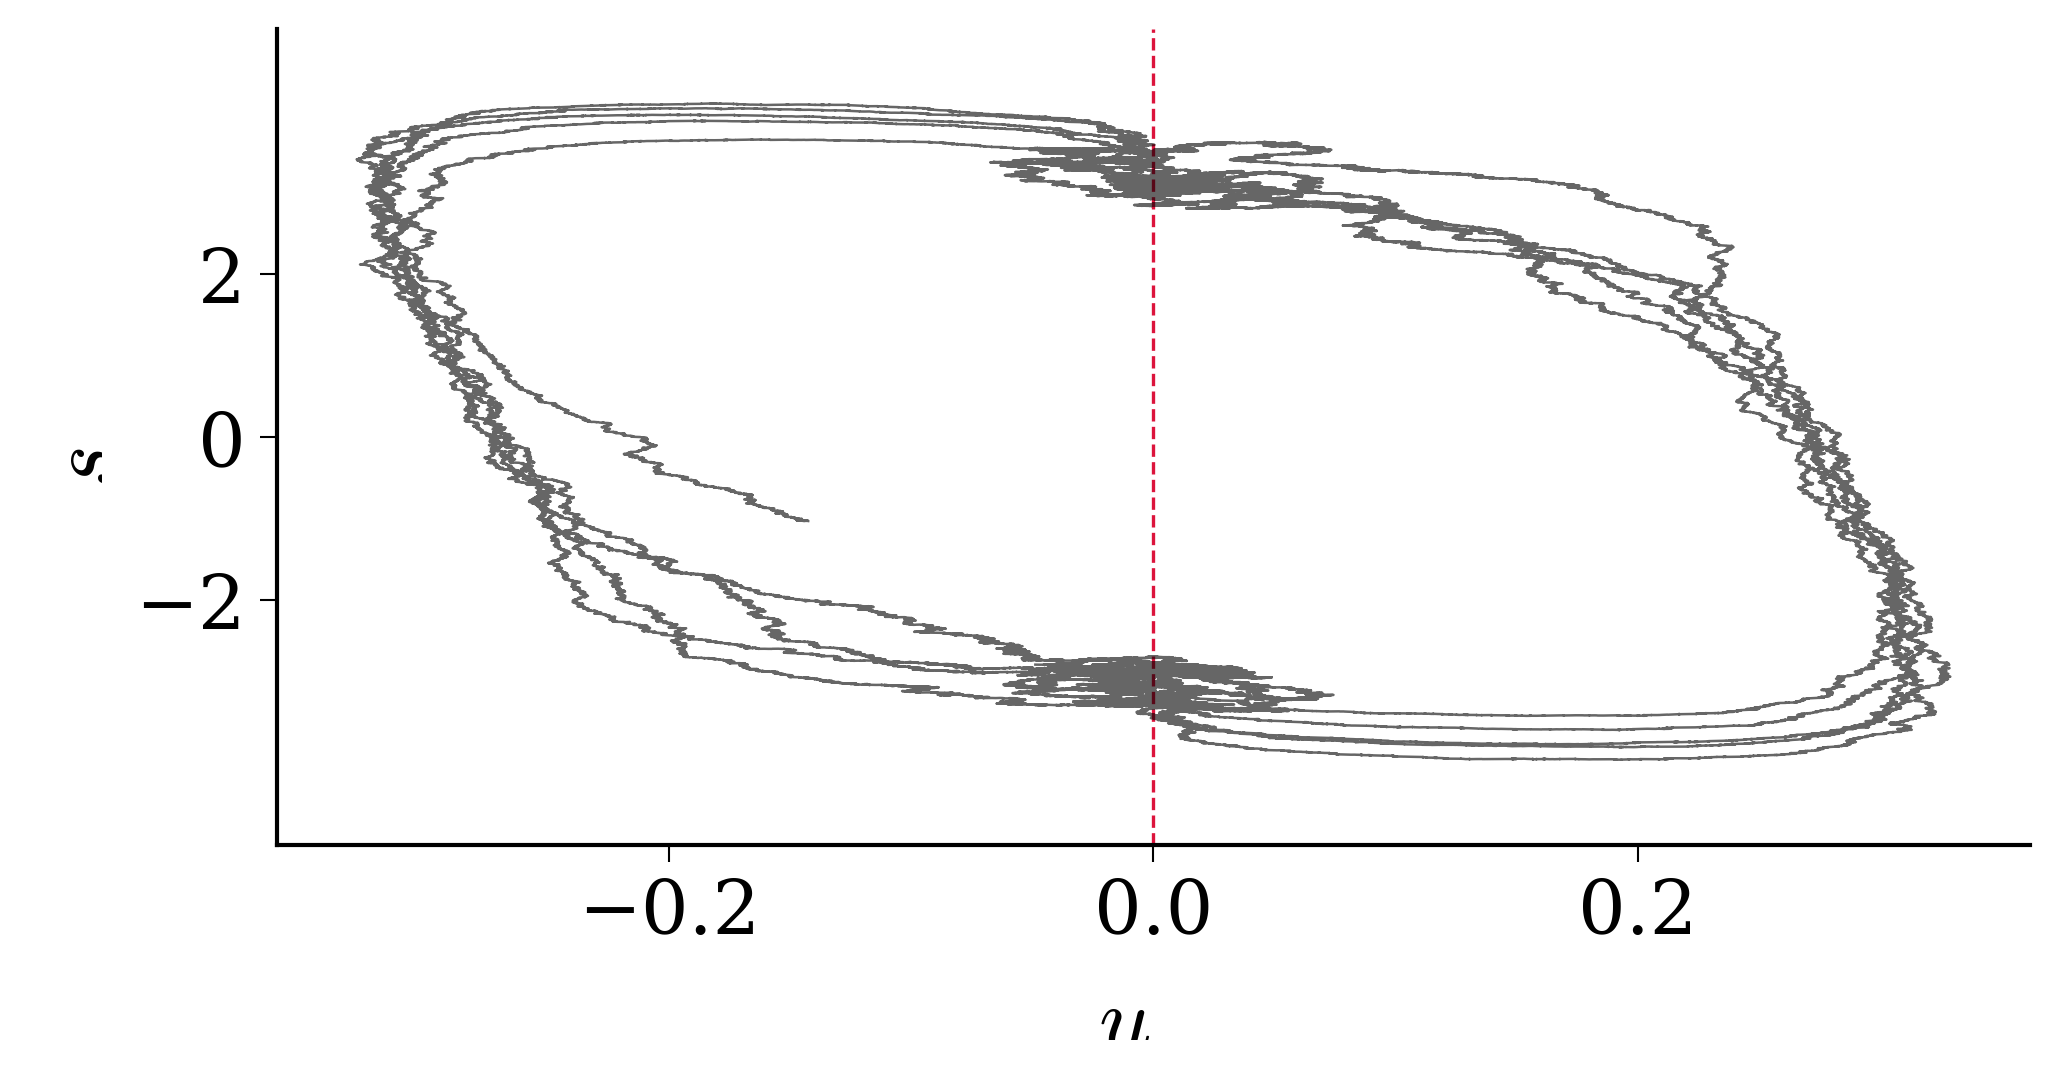

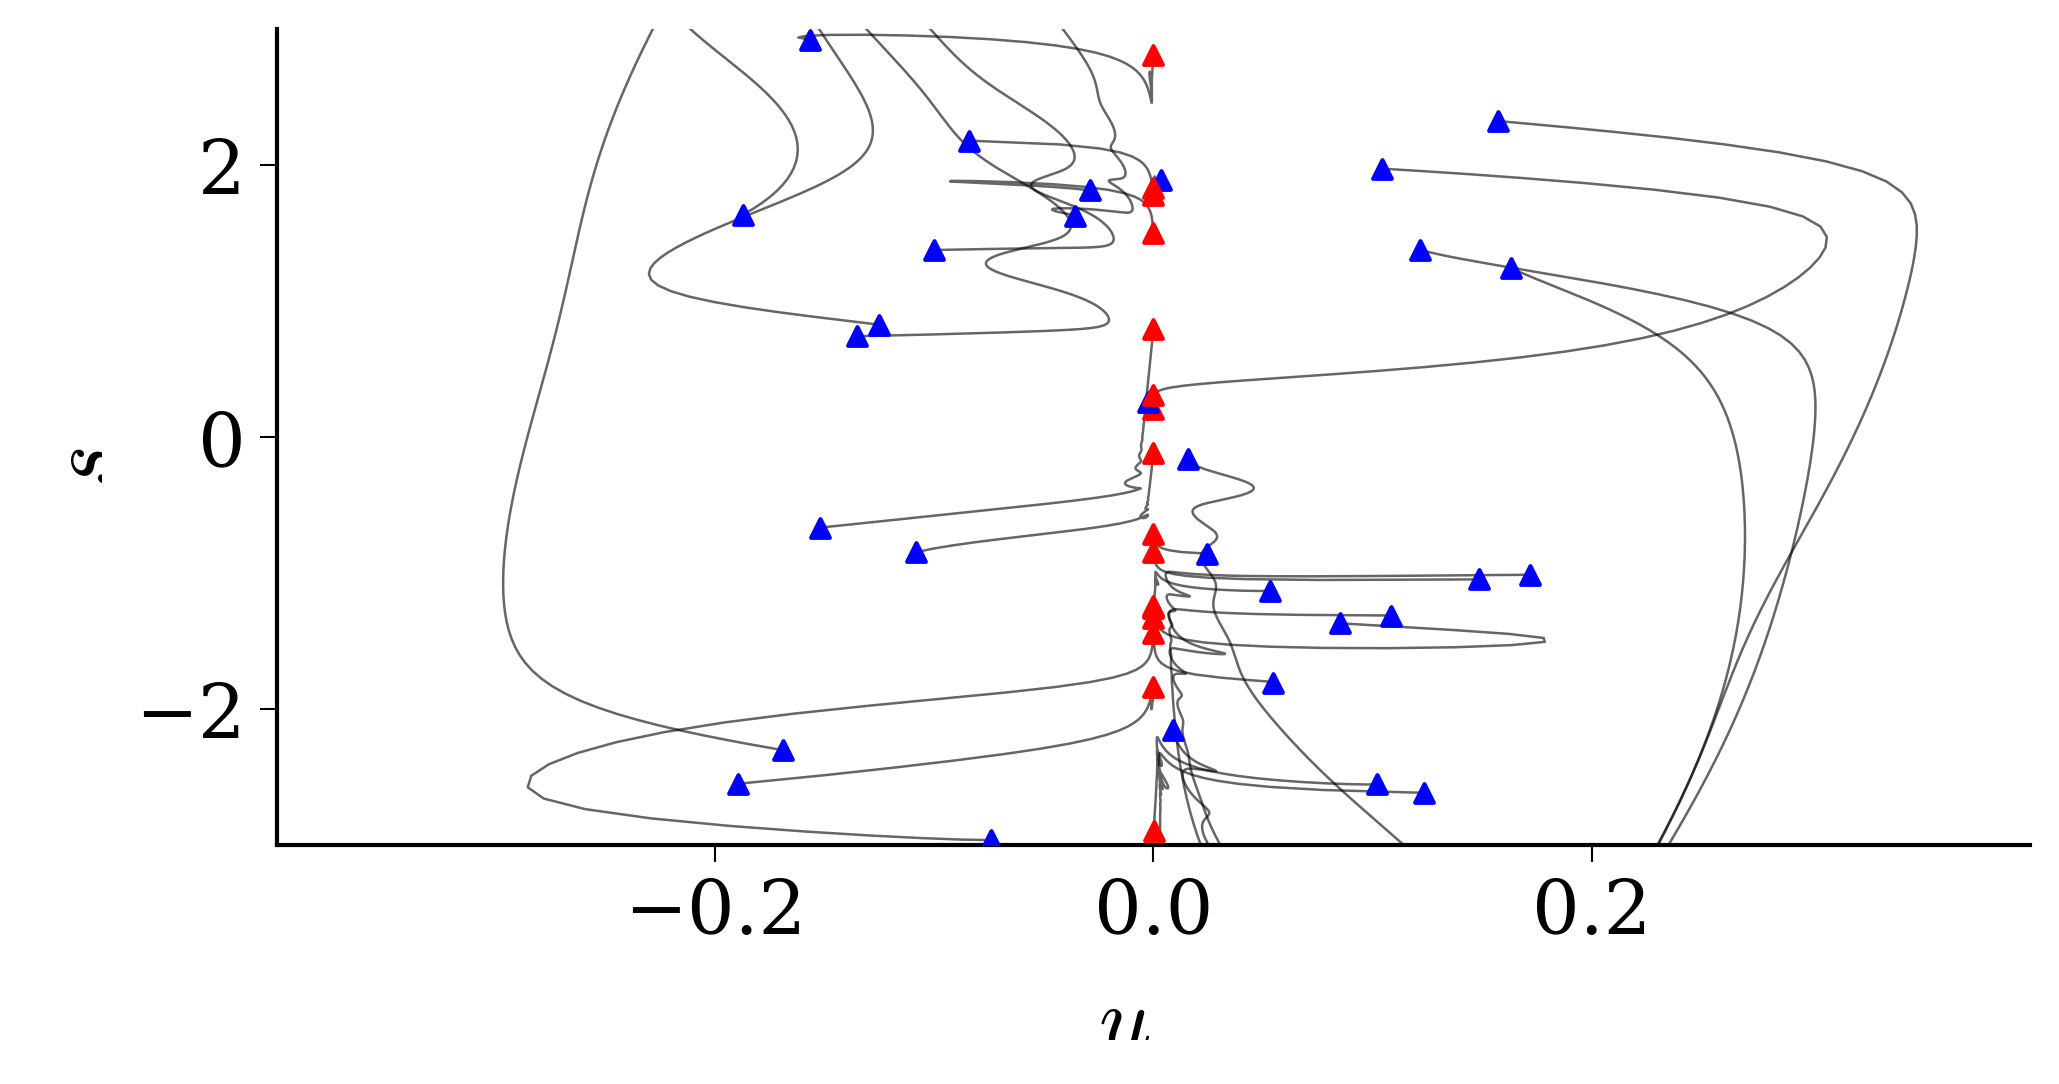

In [17]:
plt.style.use('/Users/lhc642/.config/matplotlib/stylelib/PRE_2col.mplstyle')
from scipy.integrate import solve_ivp
import numpy as np
from matplotlib import pyplot as plt


data = np.fromfile('../FIG1/data_gil_5000.bin', dtype = np.float64).reshape(6,-1)
omega=5000
X01 = data[0]/omega
X02 = data[1]/omega
X11 = data[2]/omega
X12 = data[3]/omega
V0 = data[4]
RT = data[5]

S0 = X01 + X02
S1 = X11 + X12
U0 = X01/S0
U1 = X11/S1

S_plus = S0 + S1
S_minus = S0 - S1
U_plus = (U0 + U1)/2
U_minus = (U0 - U1)/2

a=2
b=4.5
c=1
d=1

s_plus = (b*d**2+c*a**2)/(d*c*a)
u_plus = c*a**2/(c*a**2+b*d**2)
u_minus = 0

s_plus, u_plus

fig, ax1 = plt.subplots(1, 1, figsize=(6.75, 3.5))
fig1, ax2 = plt.subplots(1, 1, figsize=(6.75, 3.5))

ax1.axvline(x=u_minus, color = 'crimson', label = 'FP', lw=0.8,ls='--')
ax1.plot(U_minus[10000:200000], S_minus[10000:200000], color = 'black', lw=0.6,alpha = 0.6, label = 'Traj')


ax1.set_xlabel('$u_-$',)
ax1.set_ylabel('$s_-$',)
ax1.set_xticks([-0.2,0.,0.2])
ax1.set_yticks([-2,0,2])
ax1.set_ylim([-5, 5])



def sistema(t, s):
    s_plus, u_plus, s_minus, u_minus = s
    ds_plus  = a - d*(s_plus*u_plus - s_minus*u_minus)
    ds_minus = a*s_minus/s_plus - d*(s_minus*u_plus + s_plus*u_minus)
    du_plus  = (-b*u_plus + a*(1-u_plus)/s_plus
                - d*(u_plus - u_plus**2 - u_minus**2)
                + c*s_plus**2*(u_plus**2 + u_minus**2 - 3*u_plus*u_minus**2 - u_plus**3))
    du_minus = u_minus*(-b - a/s_plus + d*(2*u_plus - 1)
                        + c*s_plus**2*(-u_minus**2 - 3*u_plus**2 + 2*u_plus))
    return [ds_plus, du_plus, ds_minus, du_minus]


np.random.seed(42)
N = 30  # trajectory number

s_plus_0  = np.random.uniform(4, 6, N)
u_plus_0  = np.random.uniform(0.2, 0.9, N)
s_minus_0 = np.random.uniform(-3, 3, N)
u_minus_0 = np.random.uniform(-0.2, 0.2, N)

t_span = (0, 200)
t_eval = np.linspace(0, 200, 5000)


for i in range(N):
    ic = [s_plus_0[i], u_plus_0[i], s_minus_0[i], u_minus_0[i]]
    try:
        sol = solve_ivp(sistema, t_span, ic,
                        max_step=0.05, dense_output=True,
                        rtol=1e-8, atol=1e-10)
        if not sol.success:
            continue
        s = sol.sol(t_eval)
        sp, up, sm, um = s

        
        
        ax2.plot(um, sm, color = 'black', lw=0.6,alpha = 0.6)

        if i == 0:
            ax2.scatter(um[0], sm[0], s=20,marker='^', zorder=10,color = 'b',label = 'Start')
            ax2.scatter(um[-1], sm[-1], s=20,marker='^', zorder=10,color = 'r',label = 'End')
        else:
            ax2.scatter(um[0], sm[0], s=20,marker='^', zorder=10,color = 'b')
            ax2.scatter(um[-1], sm[-1], s=20,marker='^', zorder=10,color = 'r')
        #plt.scatter(sp[0], up[0], color=color, s=20, zorder=5)

    except Exception as e:
        print(f"Trajectory {i} failed: {e}")
ax2.set_xlim([-0.4, 0.4])

ax2.set_xlabel(r'$u_-$', )
ax2.set_ylabel(r'$s_-$' )
ax2.set_yticks([ -2, 0, 2,])

ax2.set_xticks([-0.2, 0.0, 0.2])

ax2.set_ylim([-3, 3])

fig.savefig('fig_usminus_traj.png')
fig1.savefig('fig_usminus_traj_ODE.png')

plt.show()

Analytical coefficients (Method-B slow-manifold reduction):
  Sp*        = 4.25000
  Up*        = 0.47059
  lambda_um  = -0.029412
  alpha      = -0.0294 (paper's alpha)
  beta      = 3.0008 (paper's beta)
  gamma      = 8.5395   (paper's gamma)
  zeta      = -4.2500 (paper's zeta)
  eta      = 0.2353 (paper's eta)

[ 9117.64705882 10257.35294118   882.35294118   992.64705882]


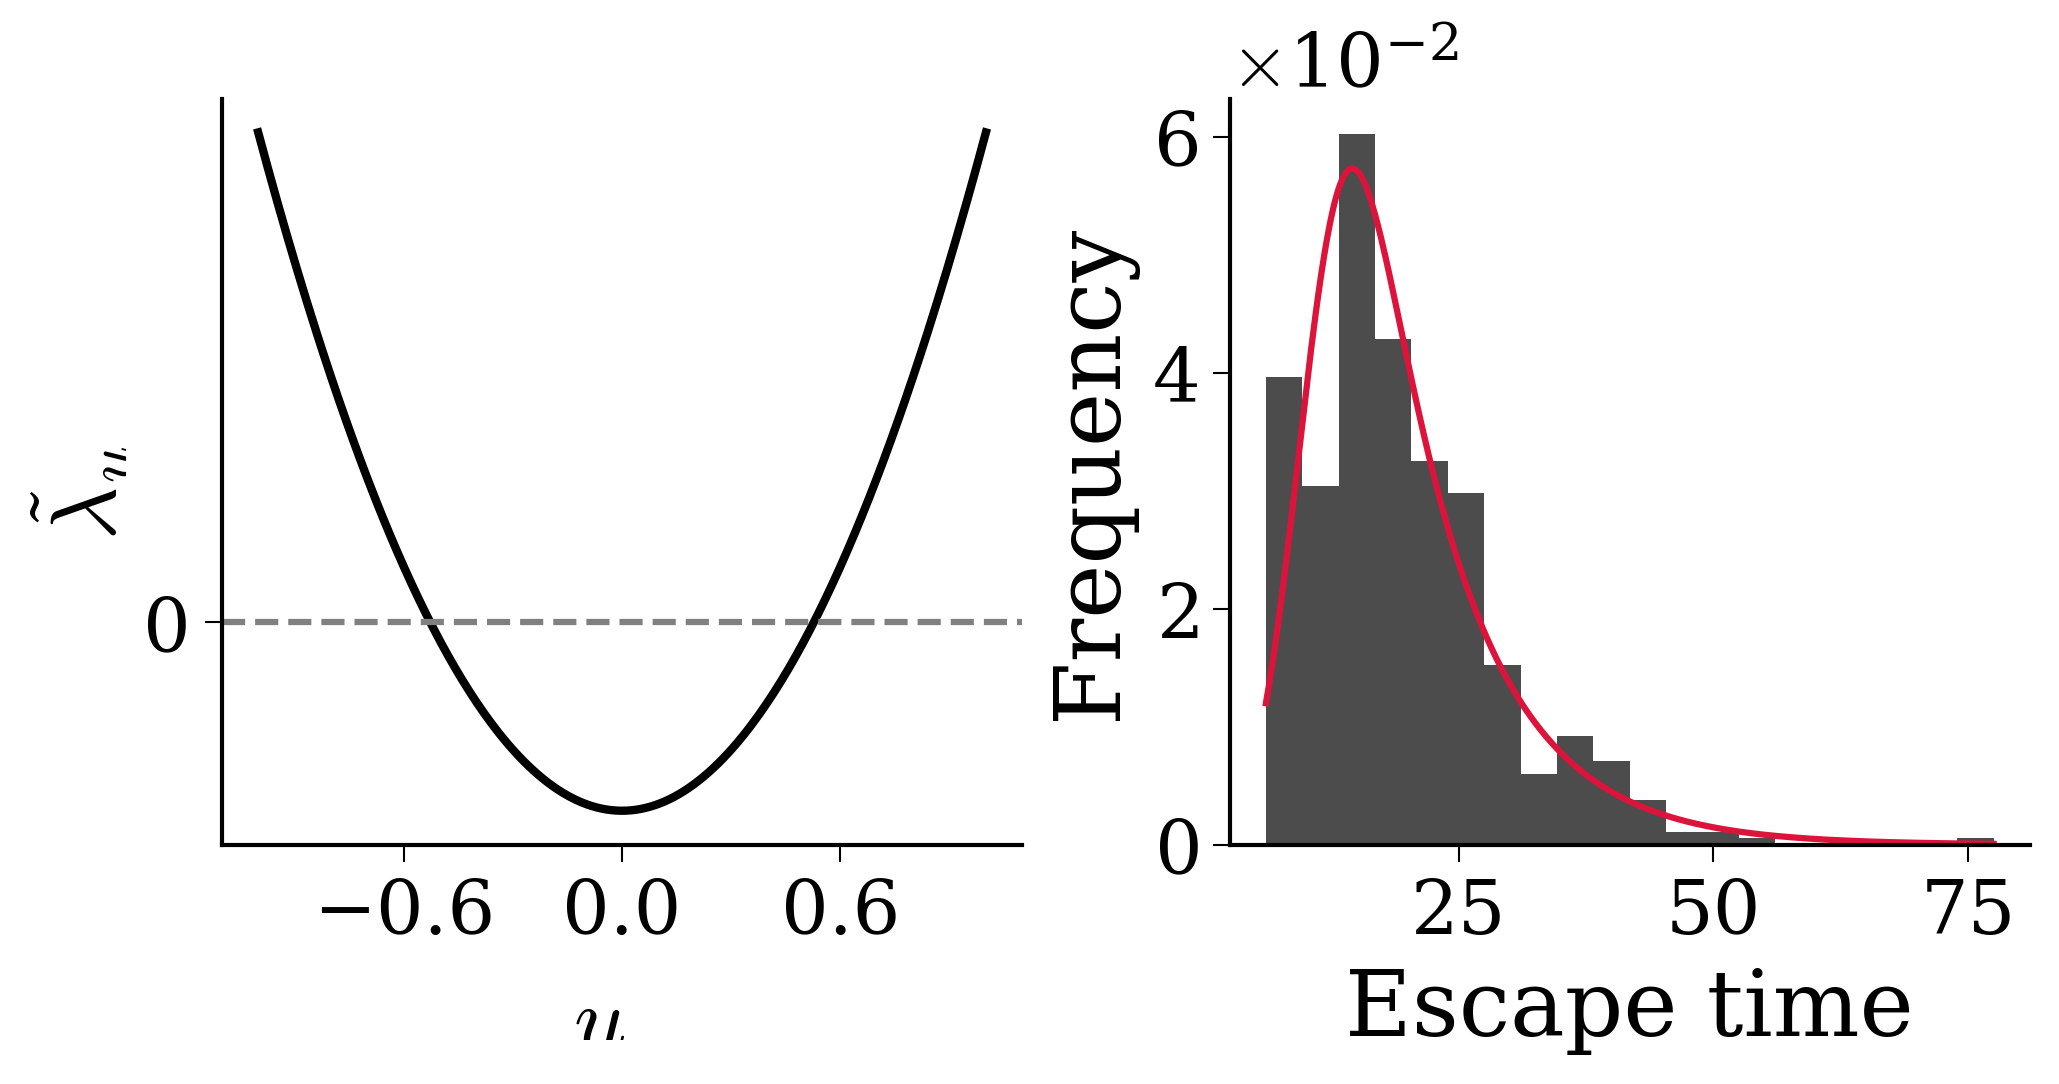

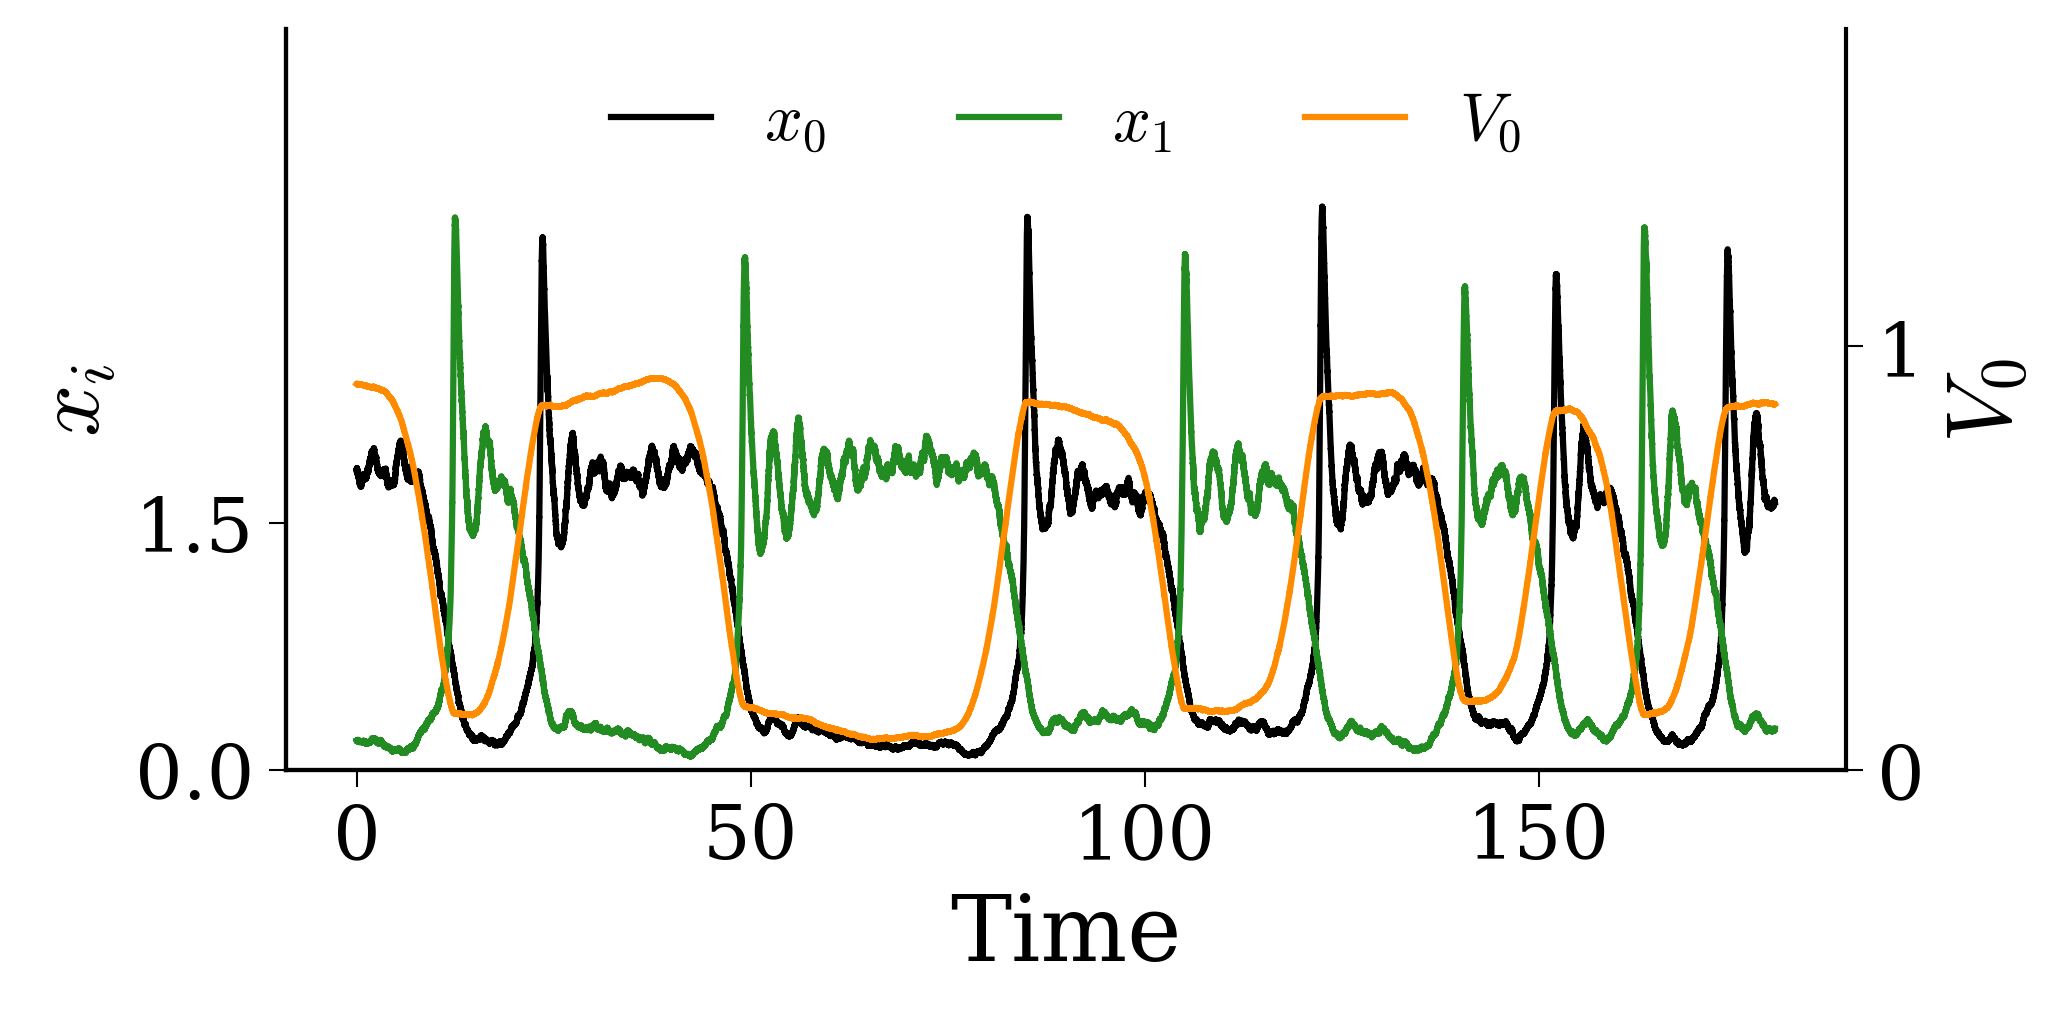

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import exponnorm
plt.style.use('/Users/lhc642/.config/matplotlib/stylelib/PRE_2col.mplstyle')

def parameters(a: float, b: float, c: float, d: float) -> dict:

    s_plus = (b*d**2+c*a**2)/(d*c*a)
    u_plus = c*a**2/(c*a**2+b*d**2)

    #coefficients computed as described in appendix C after substitution

    lambda4 = -b-a/s_plus -d*(1-2*u_plus) + c*s_plus**2*(2*u_plus - 3*u_plus**2)

    dup_sp = -a*(1-u_plus)/s_plus**2 + 2*c*s_plus*(u_plus**2 - u_plus**3)
    dup_um =(2*d + c*s_plus**2*(2 - 6*u_plus))/2

    detA = (lambda4*u_plus - s_plus*dup_sp)

    par = a/s_plus**2 + 2*c*s_plus*(2*u_plus -3*u_plus**2)

    alpha = lambda4 
    beta = -lambda4*par/(detA) + dup_sp*(c*s_plus**2*(2-6*u_plus) +2*d)/detA
    gamma = -c*s_plus**2 + par*s_plus*dup_um/detA - u_plus*dup_um*(c*s_plus**2*(2-6*u_plus)+2*d)/(detA)

    zeta = -d*(s_plus)
    eta = (lambda4*a/(s_plus**2) - d*dup_sp)/detA


    return dict(s_plus=s_plus, u_plus=u_plus, lambda_u=lambda4, alpha=alpha, beta=beta, gamma=gamma, zeta=zeta, eta=eta)

def initial_conditions(u0: float, s0: float, u_plus: float, s_plus: float) -> dict:

    x0 = (u0+u_plus)*(s0+s_plus)/2
    x1 = (u_plus-u0)*(s_plus-s0)/2
    y0 = (s0+s_plus)/2 - x0
    y1 = (s_plus-s0)/2 - x1

    return np.array([x0, y0, x1, y1])



def rk4_step_det(state: np.ndarray, h: float,
             a: float, b: float, c: float, d: float, v0: float, omega: float) -> np.ndarray:
    k1 = f_det(state, a, b, c, d, v0, omega)
    k2 = f_det(state + 0.5 * h * k1, a, b, c, d, v0, omega)
    k3 = f_det(state + 0.5 * h * k2, a, b, c, d, v0, omega)
    k4 = f_det(state + h * k3, a, b, c, d, v0, omega)
    return state + h * (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0

def f_det(state: np.ndarray, a: float, b: float, c: float, d: float, v0: float, omega: float) -> np.ndarray:
    x0, y0, x1, y1  = state

    #v1 = omega - v0
    v1 = omega - v0
    dx0 = a*v0 -(b+d)*x0 + c*x0**2*y0/(v0**2)
    dy0 = b*x0 - c*x0**2*y0/(v0**2)
    dx1 = a*v1 -(b+d)*x1 + c*x1**2*y1/(v1**2)
    dy1 = b*x1 - c*x1**2*y1/(v1**2)

    return np.array([dx0, dy0, dx1, dy1])

def f_noise(state: np.ndarray, a: float, b: float, c: float, d: float, v0: float, omega: float, rng: np.random.Generator) -> np.ndarray:
    x0, y0, x1, y1 = state
    v1 = omega - v0
    A1, A2, A3, A4 = a*v0, d*x0, b*x0, c*x0**2*y0/v0**2
    B1, B2, B3, B4 = a*v1, d*x1, b*x1, c*x1**2*y1/v1**2

    max_std = np.array([np.sqrt(A1)+np.sqrt(A2) + np.sqrt(A3) + np.sqrt(A4), np.sqrt(A3)+np.sqrt(A4), np.sqrt(B1)+np.sqrt(B2) - np.sqrt(B3) + np.sqrt(B4), np.sqrt(B3)+np.sqrt(B4)])

    dW = rng.normal(size=8) 
    dx0 = np.sqrt(A1)*dW[0] - np.sqrt(A2)*dW[1] - np.sqrt(A3)*dW[2] + np.sqrt(A4)*dW[3]
    dy0 = np.sqrt(A3)*dW[2] - np.sqrt(A4)*dW[3]
    dx1 = np.sqrt(B1)*dW[4] - np.sqrt(B2)*dW[5] - np.sqrt(B3)*dW[6] + np.sqrt(B4)*dW[7]
    dy1 = np.sqrt(B3)*dW[6] - np.sqrt(B4)*dW[7]
    return np.array([dx0, dy0, dx1, dy1]), max_std



def Euler_Maruyama(state: np.ndarray, t0: float, T: float, dt: float,a: float, b: float, c: float, d: float,seed=None,Vol:float=5000):

    rng = np.random.default_rng(seed)
    n_steps = int((T - t0) / dt)
    n = len(state)
    exit = False
    n_break = n_steps
    x0, y0, x1, y1 = state

    t = np.linspace(t0, T, n_steps + 1)
    traj = np.full((n_steps + 1, n), np.nan)
    traj[0] = state.copy()
    arr_std_u = np.full((n_steps, 1), np.nan)
    for i in range(n_steps):
        v0 = (state[0] + state[1])*Vol/(state[0] + state[1] + state[2] + state[3])
        if (v0-(Vol -v0)) < 0:
            exit = True
            n_break = i+1
            #break

        delta, max_std =  f_noise(state, a, b, c, d, v0, Vol, rng) 
        step_det = rk4_step_det(state, dt, a, b, c, d, v0, Vol)   
        arr_std_u[i] = err_u(state, max_std) * np.sqrt(dt)
        state = step_det  + delta * np.sqrt(dt)
        if np.any(state < 0):
            print(f"Warning: State has become negative at step {i}. Stopping integration.")
            print(f"State: {state}")
            break
        traj[i + 1] = state
        
    
    return t, traj, arr_std_u, exit, n_break

def nullcline(s_arr: np.ndarray, lambda_u:float, beta:float, gamma:float) -> np.ndarray:
    """
    Analytical escape threshold |Delta u_-| as a function of s_-.
    Uses the rationalised form to remain numerically stable at s_- = 0.
    return both brances of the solution
    """

    disc = np.sqrt(beta * beta * s_arr * s_arr - 4.0 * gamma * lambda_u)
    return [(-beta *s_arr + disc) / (2.0 * gamma), (-beta * s_arr - disc) / (2.0 * gamma)]

def reduced_variables(traj: np.ndarray) -> np.ndarray:
    s0 = traj[:,0] + traj[:,1]
    s1 = traj[:,2] + traj[:,3]
    u0 = (traj[:,0] / s0) /2
    u1 = (traj[:,2] / s1) /2
    sm = s0 - s1
    sp = s0 + s1
    um = u0 - u1
    up = u0 + u1
    return np.array([sp,up,sm,um])

def err_u(state: np.ndarray, delta: np.ndarray) -> float:
    x0, y0, x1, y1 = state
    dx0, dy0, dx1, dy1 = delta
    delta_u_1 = 0.5*(y0*dx0/(x0+y0)**2 - x0*dy0/(x0+y0)**2 - y1*dx1/(x1+y1)**2 + x1*dy1/(x1+y1)**2)
    delta_u_2 = 0.5*0.5*(-2*y0*(dx0)**2/(x0+y0)**3 + 2*(x0-y0)*dx0*dy0/(x0+y0)**3 + 2*x0*(dy0)**2/(x0+y0)**3 + 2*y1*(dx1)**2/(x1+y1)**3 - 2*(x1-y1)*dx1*dy1/(x1+y1)**3 - 2*x1*(dy1)**2/(x1+y1)**3)
    return delta_u_1 + delta_u_2

def function(u):
    a=2
    b=4.5
    c=1
    d=1

    s_plus = (b*d**2+c*a**2)/(d*c*a)
    u_plus = c*a**2/(c*a**2+b*d**2)
    u_minus = 0

    return a/s_plus**2 +2*c*s_plus*(2*u_plus - 3*u_plus**2) +(c*s_plus**2*(2-6*u_plus)+2*d)*(-a*(1-u_plus)/s_plus**2 + 2*c*s_plus*(u_plus**2 + u**2 -3*u_plus*u**2 - u_plus**3))

def main() -> None:
    a, b, c, d = 2.0, 4.5, 1.0, 1.0
    coeffs = parameters(a, b, c, d)
    Sp_star = coeffs["s_plus"]

    print("Analytical coefficients (Method-B slow-manifold reduction):")
    print(f"  Sp*        = {coeffs['s_plus']:.5f}")
    print(f"  Up*        = {coeffs['u_plus']:.5f}")
    print(f"  lambda_um  = {coeffs['lambda_u']:.6f}")
    print(f"  alpha      = {coeffs['alpha']:.4f} (paper's alpha)")
    print(f"  beta      = {coeffs['beta']:.4f} (paper's beta)")
    print(f"  gamma      = {coeffs['gamma']:.4f}   (paper's gamma)")
    print(f"  zeta      = {coeffs['zeta']:.4f} (paper's zeta)")
    print(f"  eta      = {coeffs['eta']:.4f} (paper's eta)")
    print()

    #T=10000.0
    T=10000
    dt=0.001
    s0 =3.5
    #u0 = nullcline(s0, coeffs['lambda_u'], coeffs['beta'], coeffs['gamma'])[0] 
    u0 = 0
    Vol = 5000.0
    N_traj = 1
    period = []
    ic = initial_conditions(u0, s0, coeffs['u_plus'], coeffs['s_plus']) * Vol
    print(ic)
    
    t, traj, arr_std_u, exit,n_break = Euler_Maruyama(ic, 0.0, T, dt, a=a, b=b, c=c, d=d, Vol=Vol)
    
    if exit:
        period.append(t[n_break])
    traj = traj / Vol
    traj_reduced = reduced_variables(traj)


    threshold = 2 
    min_period = 3

    crossings = np.where(
        ((traj_reduced[2,:-1] < threshold) & (traj_reduced[2,1:] >= threshold)) |
        ((traj_reduced[2,:-1] >= threshold) & (traj_reduced[2,1:] < threshold))
    )[0]

    t_cross  = t[crossings]
    periods  = np.diff(t_cross)
    periods  = periods[periods > min_period]


    fig,ax = plt.subplots(1,2,figsize=(6.75, 3.5))

    epsilon = 0.01
    u_test = np.linspace(-1, 1, 300) 
    #lambda4 = -b-a/coeffs['s_plus'] -d*(1-2*coeffs['u_plus']) + c*coeffs['s_plus']**2*(2*coeffs['u_plus'] - 3*coeffs['u_plus']**2)
    ax[0].plot(u_test, epsilon*function(u_test)+coeffs['lambda_u'], color='black', lw=2)
    ax[0].axhline(y=-0, color='gray', lw=1.5, ls='--')

    ax[0].set_xlabel(r'$u_{-}$',)
    ax[0].set_ylabel(r'$\tilde{\lambda}_{u_-}$',)


    ax[0].set_yticks([  0,])
    ax[0].set_xticks([ -0.6, 0, 0.6,])

    K, mu, sigma = exponnorm.fit(periods)

    x_fit = np.linspace(periods.min(), periods.max(), 500)
    y_fit = exponnorm.pdf(x_fit, K, mu, sigma)

    ax[1].hist(periods, bins=20, density=True, color='black', alpha=0.7, label='Periods')
    ax[1].plot(x_fit, y_fit, color='crimson', linewidth=1.5,
        label=f'Fit')
    ax[1].ticklabel_format(style='sci',axis='y',scilimits=(0, 0),useMathText=True)

    ax[1].set_xlabel("Escape time")
    ax[1].set_ylabel("Frequency")
    
    plt.show()

    final = 180000
    fig1, ax = plt.subplots(1, 1,figsize=(6.75, 3.25))
    ax2 = ax.twinx()
    
    plt1 = ax.plot(t[:final], traj[:final,0], color='black', label=f'$x_0$')
    plt2 = ax.plot(t[:final], traj[:final,2], color='forestgreen', label=f'$x_1$')
    plt3 = ax2.plot(t[:final], ( traj[:final,0] + traj[:final,1])/( traj[:final,0] + traj[:final,1] + traj[:final,2] + traj[:final,3]), color='darkorange', label=f'$V_0$')

    lns = [plt1[0], plt2[0], plt3[0]]
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, ncol=3,loc='upper center',fontsize=16)

    ax.set_xlabel('Time')
    ax.set_ylabel('$x_i$')
    ax.set_ylim(0, 4.5)
    ax2.set_ylabel('$V_0$')
    ax.set_yticks(np.array([0,1.5]))
    ax2.set_ylim(0, 1.75)
    ax2.set_yticks(np.arange(0, 2, 1))

    ax2.spines['right'].set_visible(True) 

    fig.savefig('parabola_period.png')
    fig1.savefig('cle.png')

    plt.show()
if __name__ == "__main__":
    main()